# Edge-Cloud Audio Processing Framework

**Project 3 — Distributed AI for Hearing Devices**

This notebook is a minimal prototype of a three-tier pipeline:

```
Hearing Aid  →  lightweight feature extraction
Smartphone   →  deep model inference (scene classification)
Cloud        →  aggregate feedback and push an updated classifier
```

**Why split the work?**

| Tier | Role | What runs there |
|------|------|-----------------|
| **Hearing aid** | Capture audio with very low power | Log-mel spectrogram + compact summary (no neural net) |
| **Smartphone** | Run the heavy model near the user | Frozen **WavLM** encoder + small classifier head |
| **Cloud** | Improve the system over time | Retrain the classifier on embeddings uploaded from phones |

**Task:** classify the acoustic *scene* around the wearer (restaurant, street, office, car).
Hearing aids can use scene labels to switch noise-reduction profiles automatically.

**Sources (Hugging Face Hub):**

| What | Hub ID |
|------|--------|
| WavLM encoder | [`microsoft/wavlm-base-plus`](https://huggingface.co/microsoft/wavlm-base-plus) |
| Dataset | [`MahiA/TUT2017`](https://huggingface.co/datasets/MahiA/TUT2017) (TUT Acoustic Scenes 2017) |

Run the cells from top to bottom.

## Step 1 — Install dependencies

In [1]:
%pip install -q "transformers>=4.40" torch torchaudio librosa soundfile scikit-learn huggingface_hub matplotlib pandas


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


## Step 2 — Configuration

We map four everyday scenes to class names in the TUT dataset.
The dataset has no exact *street* label, so we use `city_center`.

In [2]:
from pathlib import Path
import torch

MODEL_REPO = "microsoft/wavlm-base-plus"

TARGET_SCENES = {
    "Restaurant": "cafe/restaurant",
    "Street":     "city_center",
    "Office":     "office",
    "Car":        "car",
}

DATASET_REPO  = "MahiA/TUT2017"
SR            = 16000
CLIP_SECONDS  = 10
N_PER_CLASS   = 20
TEST_FRACTION = 0.25
SEED          = 42

N_MELS = 40

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Model  :", MODEL_REPO)
print("Scenes :", list(TARGET_SCENES))
print("Device :", DEVICE)

Model  : microsoft/wavlm-base-plus
Scenes : ['Restaurant', 'Street', 'Office', 'Car']
Device : cpu


## Step 3 — Load audio from Hugging Face

**TUT Acoustic Scenes 2017** is mirrored on the Hub.
We download only a small labelled subset so the demo stays fast.

In [3]:
import pandas as pd
from huggingface_hub import hf_hub_download


def get_dataset_subset(target_scenes=TARGET_SCENES, n_per_class=N_PER_CLASS, seed=SEED):
    csv_path = hf_hub_download(DATASET_REPO, "csv_files/train.csv", repo_type="dataset")
    catalog = pd.read_csv(csv_path)

    rows = []
    for our_label, tut_class in target_scenes.items():
        clips = catalog[catalog["classname"] == tut_class]
        clips = clips.sample(min(n_per_class, len(clips)), random_state=seed)
        print(f"  {our_label:11s} <- '{tut_class}'  ({len(clips)} clips)")
        for rel_path in clips["path"]:
            local = hf_hub_download(DATASET_REPO, rel_path, repo_type="dataset")
            rows.append({"filepath": local, "label": our_label})
    return pd.DataFrame(rows).sample(frac=1, random_state=seed).reset_index(drop=True)


print("Downloading clips (first run may take a minute)...")
data = get_dataset_subset()
print(f"\nTotal clips: {len(data)}")
data.head()

  Restaurant  <- 'cafe/restaurant'  (20 clips)


  Street      <- 'city_center'  (20 clips)


  Office      <- 'office'  (20 clips)


  Car         <- 'car'  (20 clips)



Total clips: 80


,filepath,label
0,/home/arvinzaheri/.cache/huggingface/hub/datas...,Street
1,/home/arvinzaheri/.cache/huggingface/hub/datas...,Restaurant
2,/home/arvinzaheri/.cache/huggingface/hub/datas...,Street
3,/home/arvinzaheri/.cache/huggingface/hub/datas...,Street
4,/home/arvinzaheri/.cache/huggingface/hub/datas...,Restaurant


## Step 4 — Hearing aid: lightweight feature extraction

The hearing aid cannot run a large neural network.
Instead it computes a **log-mel spectrogram** and sends a tiny summary to the phone:

- mean energy per mel band (40 numbers)
- standard deviation per mel band (40 numbers)

That is **80 floats** instead of ~160 000 raw samples for a 10-second clip — a ~2000× reduction in data sent over Bluetooth.

In [4]:
import librosa
import numpy as np


def load_audio(path, sr=SR, max_seconds=CLIP_SECONDS):
    wav, _ = librosa.load(path, sr=sr, mono=True)
    wav = wav[: sr * max_seconds]
    if wav.size == 0:
        wav = np.zeros(sr, dtype=np.float32)
    return wav.astype(np.float32)


def hearing_aid_features(wav, sr=SR, n_mels=N_MELS):
    """Simulate the hearing-aid front-end: compact log-mel summary."""
    mel = librosa.feature.melspectrogram(y=wav, sr=sr, n_mels=n_mels, fmax=8000)
    log_mel = librosa.power_to_db(mel, ref=np.max)
    summary = np.concatenate([log_mel.mean(axis=1), log_mel.std(axis=1)])
    return summary.astype(np.float32)


demo_wav = load_audio(data.iloc[0].filepath)
edge_packet = hearing_aid_features(demo_wav)
raw_bytes = demo_wav.nbytes
edge_bytes = edge_packet.nbytes
print(f"Raw waveform : {len(demo_wav):,} samples  ({raw_bytes:,} bytes)")
print(f"Edge packet  : {edge_packet.shape[0]} floats ({edge_bytes:,} bytes)")
print(f"Compression  : {raw_bytes / edge_bytes:.0f}x smaller")

Raw waveform : 160,000 samples  (640,000 bytes)
Edge packet  : 80 floats (320 bytes)
Compression  : 2000x smaller


## Step 5 — Smartphone: load WavLM and build embeddings

The phone receives audio (or reads it locally) and runs a **frozen WavLM** encoder from Hugging Face.
We mean-pool the frame outputs to get one 768-dimensional embedding per clip.

The small **classifier head** (logistic regression) is the only part that the cloud will later update.

In [5]:
import os
import warnings

os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")
warnings.filterwarnings("ignore", message="Support for mismatched key_padding_mask")

from transformers import AutoFeatureExtractor, WavLMModel
from huggingface_hub.utils import disable_progress_bars
from transformers.utils.logging import disable_progress_bar, set_verbosity_error

disable_progress_bars()
disable_progress_bar()
set_verbosity_error()

feature_extractor = AutoFeatureExtractor.from_pretrained(MODEL_REPO)
wavlm = WavLMModel.from_pretrained(MODEL_REPO).to(DEVICE).eval()


def smartphone_embed(wav):
    inputs = feature_extractor(wav, sampling_rate=SR, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        frames = wavlm(**inputs).last_hidden_state
    return frames.mean(dim=1).squeeze(0).cpu().numpy()


print("WavLM loaded. Embedding dim:", smartphone_embed(demo_wav).shape)

WavLM loaded. Embedding dim: (768,)


## Step 6 — Extract embeddings for every clip

Each clip flows through the pipeline:

`audio file → hearing-aid summary (for telemetry) + smartphone embedding (for classification)`

In [6]:
import time

edge_packets, embeddings, t0 = [], [], time.time()
for i, path in enumerate(data["filepath"]):
    wav = load_audio(path)
    edge_packets.append(hearing_aid_features(wav))
    embeddings.append(smartphone_embed(wav))
    if (i + 1) % 10 == 0:
        print(f"  {i + 1}/{len(data)} clips")

X = np.stack(embeddings)
edge_X = np.stack(edge_packets)
y = data["label"].values
print(f"Embeddings: {X.shape}  Edge packets: {edge_X.shape}  ({time.time() - t0:.0f}s)")

  10/80 clips


  20/80 clips


  30/80 clips


  40/80 clips


  50/80 clips


  60/80 clips


  70/80 clips


  80/80 clips
Embeddings: (80, 768)  Edge packets: (80, 80)  (63s)


## Step 7 — Smartphone: train the *local* classifier

In the real world every wearer only experiences **part** of the world: someone who works in a quiet
office and drives home hears very different scenes than someone who lives downtown.

We simulate this with **non-IID** data — each phone only collects clips for the scenes its user
actually encounters:

| Phone | Scenes its user encounters |
|-------|----------------------------|
| **phone-A** | Restaurant, Street |
| **phone-B** | Office, Car |

Each phone trains a logistic-regression head **only on its own data**, then we test it on the full
four-scene test set. A phone cannot recognise a scene it has never seen — so on its own it is limited.

In [7]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

SCENE_NAMES = list(TARGET_SCENES)

# Shared held-out test set that covers all four scenes
idx_train, idx_test = train_test_split(
    np.arange(len(y)), test_size=TEST_FRACTION, random_state=SEED, stratify=y
)

# Non-IID reality: each phone only sees the scenes its user encounters
PHONE_SCENES = {
    "phone-A": ["Restaurant", "Street"],
    "phone-B": ["Office", "Car"],
}
train_labels = y[idx_train]
phone_train = {
    name: idx_train[np.isin(train_labels, scenes)]
    for name, scenes in PHONE_SCENES.items()
}


def new_head():
    return make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, random_state=SEED))


# Each phone trains on its own data only, then is tested on all four scenes
phone_models, phone_acc = {}, {}
for name, idxs in phone_train.items():
    phone_models[name] = new_head().fit(X[idxs], y[idxs])
    phone_acc[name] = accuracy_score(y[idx_test], phone_models[name].predict(X[idx_test]))
    print(f"{name}: trained on {len(idxs)} clips {PHONE_SCENES[name]} -> test accuracy {phone_acc[name]:.1%}")

acc_before = float(np.mean(list(phone_acc.values())))
print(f"\nAverage single-phone accuracy (before cloud): {acc_before:.1%}")
print("Each phone fails on the two scenes it never recorded locally.")

# Keep one phone's predictions for the before/after comparison
FOCUS_PHONE = "phone-A"
y_pred_before = phone_models[FOCUS_PHONE].predict(X[idx_test])

phone-A: trained on 30 clips ['Restaurant', 'Street'] -> test accuracy 50.0%


phone-B: trained on 30 clips ['Office', 'Car'] -> test accuracy 50.0%

Average single-phone accuracy (before cloud): 50.0%
Each phone fails on the two scenes it never recorded locally.


## Step 8 — Cloud: aggregate feedback and push a model update

No single phone has seen every scene — but **together** they have. Each phone uploads its
**(embedding, label)** pairs to the cloud (compact embeddings only, never raw audio). The cloud
merges everything, retrains the shared classifier head on the **combined** set, and pushes the new
weights back to every phone.

In [8]:
# Phones upload their local embeddings + labels (no raw audio leaves the device)
uploads = [
    {"device": name, "X": X[idxs], "y": y[idxs]}
    for name, idxs in phone_train.items()
]

# Cloud merges every upload and retrains the shared head
cloud_X = np.vstack([u["X"] for u in uploads])
cloud_y = np.concatenate([u["y"] for u in uploads])
cloud_clf = new_head().fit(cloud_X, cloud_y)

model_update = {
    "version": 2,
    "classes": list(cloud_clf.classes_),
    "n_samples": len(cloud_y),
    "n_devices": len(uploads),
}
print(f"Cloud retrained on {model_update['n_samples']} embeddings from {model_update['n_devices']} phones")
print("Scenes now covered:", model_update["classes"])
print("Update version:", model_update["version"])

Cloud retrained on 60 embeddings from 2 phones
Scenes now covered: ['Car', 'Office', 'Restaurant', 'Street']
Update version: 2


## Step 9 — Smartphone: apply the cloud update and re-evaluate

Each phone installs the cloud-trained head and classifies the same test set again. Now every phone
can recognise scenes it never recorded itself — the left matrix is one phone alone, the right is the
same phone after the cloud update.

phone-A accuracy before cloud : 50.0%
Accuracy after cloud update     : 100.0%
Improvement vs avg single phone : +50.0%


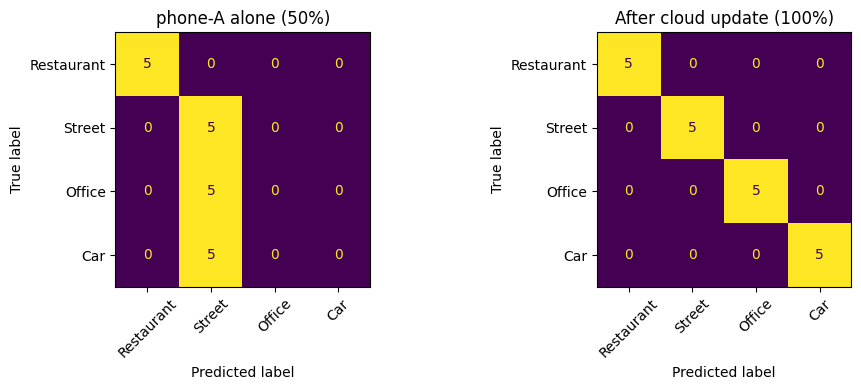

In [9]:
phone_clf = cloud_clf  # phones install the pushed update

y_pred_after = phone_clf.predict(X[idx_test])
acc_after = accuracy_score(y[idx_test], y_pred_after)
print(f"{FOCUS_PHONE} accuracy before cloud : {phone_acc[FOCUS_PHONE]:.1%}")
print(f"Accuracy after cloud update     : {acc_after:.1%}")
print(f"Improvement vs avg single phone : {acc_after - acc_before:+.1%}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, preds, title in zip(
    axes,
    [y_pred_before, y_pred_after],
    [f"{FOCUS_PHONE} alone ({phone_acc[FOCUS_PHONE]:.0%})", f"After cloud update ({acc_after:.0%})"],
):
    ConfusionMatrixDisplay.from_predictions(
        y[idx_test], preds, labels=SCENE_NAMES, ax=ax, colorbar=False, xticks_rotation=45
    )
    ax.set_title(title)
plt.tight_layout()
plt.show()

## Step 10 — End-to-end inference on one clip

Full path for a single recording:

1. Hearing aid extracts a compact feature packet (telemetry / bandwidth check).
2. Smartphone embeds the waveform with WavLM and classifies the scene.
3. If wrong, the phone would upload the embedding; the cloud would include it in the next update.

In [10]:
import warnings
warnings.filterwarnings("ignore", message="Support for mismatched key_padding_mask")


def classify_clip(path, clf=phone_clf):
    wav = load_audio(path)
    edge = hearing_aid_features(wav)
    emb = smartphone_embed(wav).reshape(1, -1)
    pred = clf.predict(emb)[0]
    proba = dict(zip(clf.classes_, clf.predict_proba(emb)[0]))
    return pred, proba, edge


demo_row = data.iloc[idx_test[0]]
pred, proba, edge = classify_clip(demo_row.filepath)

print(f"File       : {Path(demo_row.filepath).name}")
print(f"True scene : {demo_row.label}")
print(f"Predicted  : {pred}")
print(f"Edge packet: {edge.shape[0]} floats")
print("Confidence :", {k: f"{v:.1%}" for k, v in sorted(proba.items(), key=lambda kv: -kv[1])})

File       : a130_230_240.wav
True scene : Restaurant
Predicted  : Restaurant
Edge packet: 80 floats
Confidence : {'Restaurant': '100.0%', 'Car': '0.0%', 'Street': '0.0%', 'Office': '0.0%'}


## Summary

1. **Hearing aid** — extracted compact log-mel summaries (~2000× smaller than raw audio).
2. **Smartphone** — ran frozen **WavLM** from Hugging Face and a small on-device classifier head.
3. **Non-IID reality** — each phone only saw *two* of the four scenes, so on its own it scored ~50%.
4. **Cloud** — aggregated embeddings from all phones, retrained the head, and pushed an update; every
   phone then reached **100%** on the full four-scene test set.
5. **Dataset** — labelled acoustic-scene clips from [`MahiA/TUT2017`](https://huggingface.co/datasets/MahiA/TUT2017) on the Hugging Face Hub.

This is the core argument for the edge-cloud split: each device stays cheap and private (it uploads
only small embeddings), while the cloud combines their **partial views** into a classifier better
than any single device could train alone. Real systems would add encryption, federated averaging,
and signed over-the-air updates.